# Diffusion Models from Scratch

We'll build up a diffusion model piece by piece, starting with raw data and ending with sampling.
The goal is to understand every moving part before hiding anything behind a function.

In [1]:
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
from itertools import pairwise

%matplotlib inline
plt.rcParams['figure.figsize'] = (5, 5)
plt.rcParams['figure.dpi'] = 100

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_float32_matmul_precision("high")
print(f"Using device: {device}")

Using device: cuda


## 1. The Dataset

Let's start with points on a spiral. Nothing fancy — just `t*cos(t)` and `t*sin(t)` scaled down.

In [2]:
# Raw spiral points
N = 1000
tmin, tmax = np.pi / 2, 5 * np.pi
t = tmin + torch.linspace(0, 1, N) * tmax
points = torch.stack([t * torch.cos(t) / tmax, t * torch.sin(t) / tmax]).T
points.shape

torch.Size([1000, 2])

(np.float64(-1.0922431647777557),
 np.float64(0.8927346169948578),
 np.float64(-1.2001114755868911),
 np.float64(1.0023404628038406))

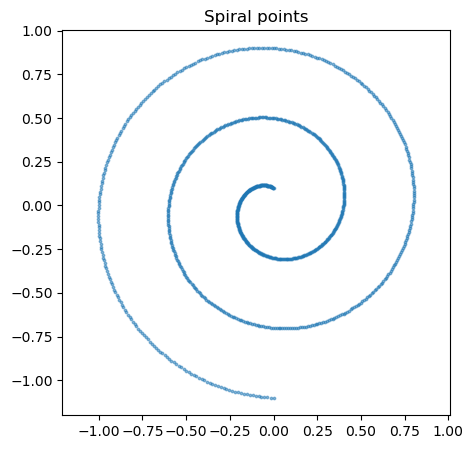

In [3]:
plt.scatter(points[:, 0], points[:, 1], s=3, alpha=0.5)
plt.title("Spiral points")
plt.axis("equal")

### What does adding noise look like?

Diffusion works by gradually adding Gaussian noise to data. The amount of noise is controlled by $\sigma$.
The noised version is simply: $x_t = x_0 + \sigma \cdot \epsilon$ where $\epsilon \sim \mathcal{N}(0, I)$.

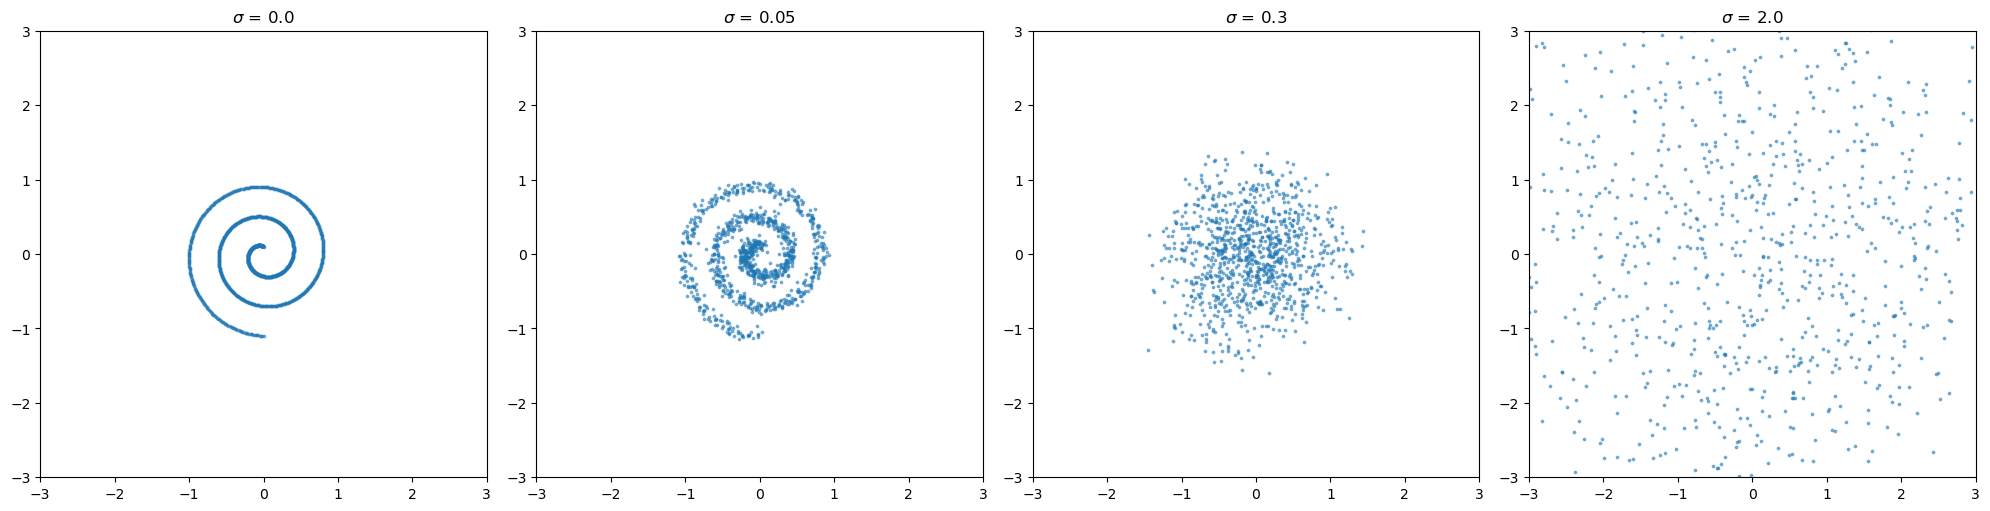

In [4]:
# Let's see what pure noise looks like vs noised spiral at different sigma levels
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, sigma in zip(axes, [0.0, 0.05, 0.3, 2.0]):
    eps = torch.randn_like(points)
    noised = points + sigma * eps
    ax.scatter(noised[:, 0], noised[:, 1], s=3, alpha=0.5)
    ax.set_title(f"$\\sigma$ = {sigma}")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal")

plt.tight_layout()

At $\sigma = 0$ we have the original spiral. As $\sigma$ grows, it becomes pure noise.

### The noise schedule

A schedule is just an increasing list of $\sigma$ values. Log-linear spacing works well for toy problems.

Schedule: 200 steps, from 0.0050 to 10.0000


Text(0.5, 1.0, 'Log-linear noise schedule')

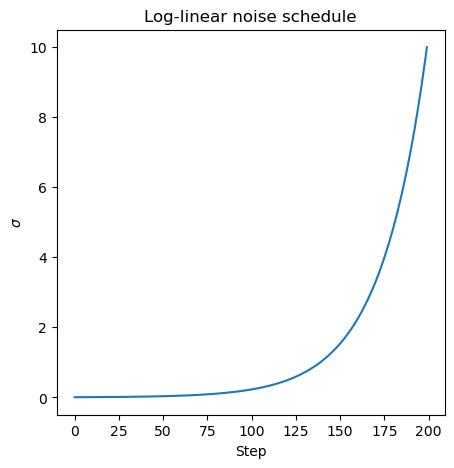

In [5]:
# Create a log-linear schedule: N sigma values from sigma_min to sigma_max
N_schedule = 200
sigma_min, sigma_max = 0.005, 10.0
sigmas = torch.logspace(math.log10(sigma_min), math.log10(sigma_max), N_schedule).to(
    device
)
print(f"Schedule: {len(sigmas)} steps, from {sigmas[0]:.4f} to {sigmas[-1]:.4f}")
plt.plot(sigmas.cpu().numpy())
plt.xlabel("Step")
plt.ylabel("$\\sigma$")
plt.title("Log-linear noise schedule")

### Sampling a training batch

During training we pick random $\sigma$ values from the schedule for each example in the batch.
Then we generate random noise $\epsilon$ and compute $x_t = x_0 + \sigma \cdot \epsilon$.

In [6]:
# Simulate one training batch
batch_size = 64
# Pick random data points (with replacement, as a DataLoader would)
idx = torch.randint(0, len(points), (batch_size,))
x0 = points[idx].to(device)

# Pick random sigma for each sample
sigma_idx = torch.randint(0, len(sigmas), (batch_size,))
sigma = sigmas[sigma_idx].unsqueeze(1)  # shape: (batch_size, 1) for broadcasting

# Generate noise and noised data
eps = torch.randn_like(x0)
xt = x0 + sigma * eps

print(f"x0: {x0.shape}, sigma: {sigma.shape}, eps: {eps.shape}, xt: {xt.shape}")

x0: torch.Size([64, 2]), sigma: torch.Size([64, 1]), eps: torch.Size([64, 2]), xt: torch.Size([64, 2])


### Wrapping it as a Dataset

Now let's package this into a proper PyTorch dataset — same as `smalldiffusion.Swissroll`.

In [7]:
from torch.utils.data import Dataset, DataLoader


class Spiral(Dataset):
    def __init__(self, tmin, tmax, N):
        t = tmin + torch.linspace(0, 1, N) * tmax
        self.vals = torch.stack([t * torch.cos(t) / tmax, t * torch.sin(t) / tmax]).T

    def __len__(self):
        return len(self.vals)

    def __getitem__(self, i):
        return self.vals[i]


dataset = Spiral(np.pi / 2, 5 * np.pi, 1000)
loader = DataLoader(dataset, batch_size=2048)
batch = next(iter(loader))
print(f"Batch shape: {batch.shape}")

Batch shape: torch.Size([1000, 2])


## 2. The Model

The model's job: given noised data $x_t$ and the noise level $\sigma$, predict the noise $\epsilon$ that was added.

We'll use a simple MLP. The only trick is how we tell the model what $\sigma$ is — we encode it
as $(\sin(0.5 \cdot \log\sigma), \cos(0.5 \cdot \log\sigma))$ and concatenate with the input.

In [8]:
# Sigma embedding: turn a scalar sigma into a 2D vector the model can use
def get_sigma_embeds(batches, sigma):
    if sigma.shape == torch.Size([]):
        sigma = sigma.unsqueeze(0).repeat(batches)
    s = torch.log(sigma).unsqueeze(1) * 0.5  # (B, 1)
    return torch.cat([torch.sin(s), torch.cos(s)], dim=1)  # (B, 2)


# Quick test
sig = torch.tensor([0.1, 1.0, 5.0])
get_sigma_embeds(3, sig)

tensor([[-0.9133,  0.4073],
        [ 0.0000,  1.0000],
        [ 0.7206,  0.6933]])

In [9]:
from torch import nn


# A minimal MLP that takes (x, sigma) -> predicted noise
# Input: 2D point + 2D sigma embed = 4 dims
class NoisePredMLP(nn.Module):
    def __init__(self, hidden_dims=(16, 128, 128, 128, 128, 16)):
        super().__init__()
        layers = []
        in_dim = 4  # 2 for data + 2 for sigma embedding
        for out_dim in hidden_dims:
            layers.extend([nn.Linear(in_dim, out_dim), nn.GELU()])
            in_dim = out_dim
        layers.append(nn.Linear(in_dim, 2))  # output same dim as data
        self.net = nn.Sequential(*layers)

    def forward(self, x, sigma):
        sigma_embeds = get_sigma_embeds(x.shape[0], sigma.squeeze())  # (B, 2)
        nn_input = torch.cat([x, sigma_embeds], dim=1)  # (B, 4)
        return self.net(nn_input)


model = NoisePredMLP().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 53,890


### One forward pass (before any training)

Let's make sure the shapes work. The model sees noised data and a sigma, and should output
something the same shape as the input (its guess at the noise).

In [10]:
x0 = batch[:8].to(device)
sigma = sigmas[torch.randint(0, len(sigmas), (8,))].unsqueeze(1)  # (8, 1)
eps = torch.randn_like(x0)
xt = x0 + sigma * eps

with torch.no_grad():
    eps_pred = model(xt, sigma)

print(f"Input xt:     {xt.shape}")
print(f"True noise:   {eps.shape}")
print(f"Predicted:    {eps_pred.shape}")
print(f"Loss (MSE):   {nn.MSELoss()(eps, eps_pred).item():.4f}  (random, untrained)")

Input xt:     torch.Size([8, 2])
True noise:   torch.Size([8, 2])
Predicted:    torch.Size([8, 2])
Loss (MSE):   0.9898  (random, untrained)


## 3. Training

The training loop is dead simple:
1. Sample a batch of data $x_0$
2. Pick random $\sigma$ from the schedule
3. Sample noise $\epsilon \sim \mathcal{N}(0, I)$
4. Compute noised input $x_t = x_0 + \sigma \cdot \epsilon$
5. Model predicts $\hat{\epsilon}(x_t, \sigma)$
6. Loss = MSE between $\epsilon$ and $\hat{\epsilon}$

Let's write it out explicitly.

100%|██████████| 15000/15000 [00:26<00:00, 568.93it/s]


Text(0.5, 1.0, 'Training loss')

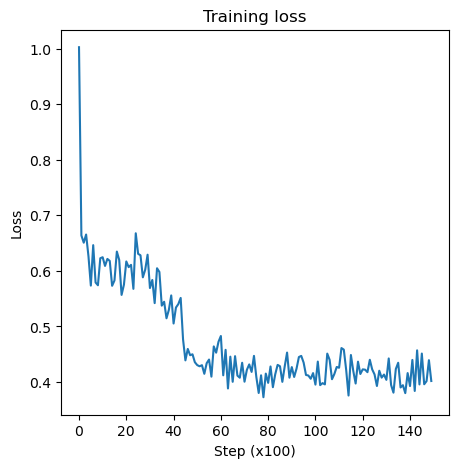

In [11]:
from tqdm import tqdm

model = NoisePredMLP().to(device)
model = torch.compile(model)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
epochs = 15000
losses = []

for epoch in (pbar := tqdm(range(epochs))):
    for x0 in loader:
        model.train()
        optimizer.zero_grad()

        x0 = x0.to(device)

        # Sample random sigmas for this batch
        sigma = sigmas[torch.randint(0, len(sigmas), (x0.shape[0],))].unsqueeze(1)

        # Add noise
        eps = torch.randn_like(x0)
        xt = x0 + sigma * eps

        # Predict noise and compute loss
        eps_pred = model(xt, sigma)
        loss = nn.MSELoss()(eps, eps_pred)

        loss.backward()
        optimizer.step()
        losses.append(loss.item())

plt.plot(losses[::100])  # plot every 100th to keep it readable
plt.xlabel("Step (x100)")
plt.ylabel("Loss")
plt.title("Training loss")

## 4. Inference (Sampling)

Sampling reverses the noising process. We start from pure noise $x_T \sim \mathcal{N}(0, \sigma_{\max}^2 I)$
and iteratively denoise using DDPM sampling.

Each step from $\sigma_t$ to $\sigma_{t-1}$ is split into a partial denoise followed by a fresh noise injection:

$$\sigma' = \frac{\sigma_{t-1}^2}{\sigma_t}, \qquad \eta = \sqrt{\sigma_{t-1}^2 - \sigma'^2}$$

$$x_{t-1} = x_t - (\sigma_t - \sigma') \cdot \hat{\epsilon}(x_t, \sigma_t) + \eta \cdot z, \qquad z \sim \mathcal{N}(0, I)$$

The intuition: instead of jumping all the way from $\sigma_t$ to $\sigma_{t-1}$ deterministically,
we take a smaller deterministic step (to $\sigma'$) and then add fresh noise ($\eta \cdot z$).
The two noise levels combine in quadrature: $\sigma'^2 + \eta^2 = \sigma_{t-1}^2$, so we land
at the correct total noise level. This stochasticity lets the sampler explore and produces
higher-quality samples than a purely deterministic approach.

### Subsampling the schedule for inference

We trained with 200 sigma values but we don't need all of them for sampling.
We subsample to get a smaller, decreasing sequence.

In [12]:
# Subsample the schedule: take `steps` evenly-spaced values, in decreasing order
# "trailing" spacing as in Table 2 of https://arxiv.org/abs/2305.08891
def sample_sigmas(sigmas, steps):
    N = len(sigmas)
    indices = list((N * (1 - np.arange(0, steps) / steps)).round().astype(np.int64) - 1)
    return sigmas[indices + [0]]  # includes the final sigma=sigma_min


sample_sigs = sample_sigmas(sigmas, 20)
print(f"{len(sample_sigs)} sigma values (20 steps + final):")
print(sample_sigs)

21 sigma values (20 steps + final):
tensor([1.0000e+01, 6.8253e+00, 4.6584e+00, 3.1795e+00, 2.1701e+00, 1.4811e+00,
        1.0109e+00, 6.8998e-01, 4.7093e-01, 3.2142e-01, 2.1938e-01, 1.4973e-01,
        1.0219e-01, 6.9751e-02, 4.7607e-02, 3.2493e-02, 2.2177e-02, 1.5136e-02,
        1.0331e-02, 7.0512e-03, 5.0000e-03], device='cuda:0')


### Explicit sampling loop

DDPM sampling with stochastic noise injection at each step.

In [13]:
@torch.no_grad()
def sample(model, sigmas, n_samples=1000):
    """DDPM sampling. Returns list of xt at every step, for visualization."""
    dev = next(model.parameters()).device
    xt = torch.randn(n_samples, 2, device=dev) * sigmas[0]  # start from noise
    trajectory = [xt.clone()]

    for sig, sig_prev in pairwise(sigmas):
        eps = model(xt, sig.expand(n_samples))
        # DDPM step: partial denoise + fresh noise injection
        sig_p = sig_prev**2 / sig
        eta = (sig_prev**2 - sig_p**2).sqrt()
        xt = xt - (sig - sig_p) * eps + eta * torch.randn_like(xt)
        trajectory.append(xt.clone())

    return trajectory

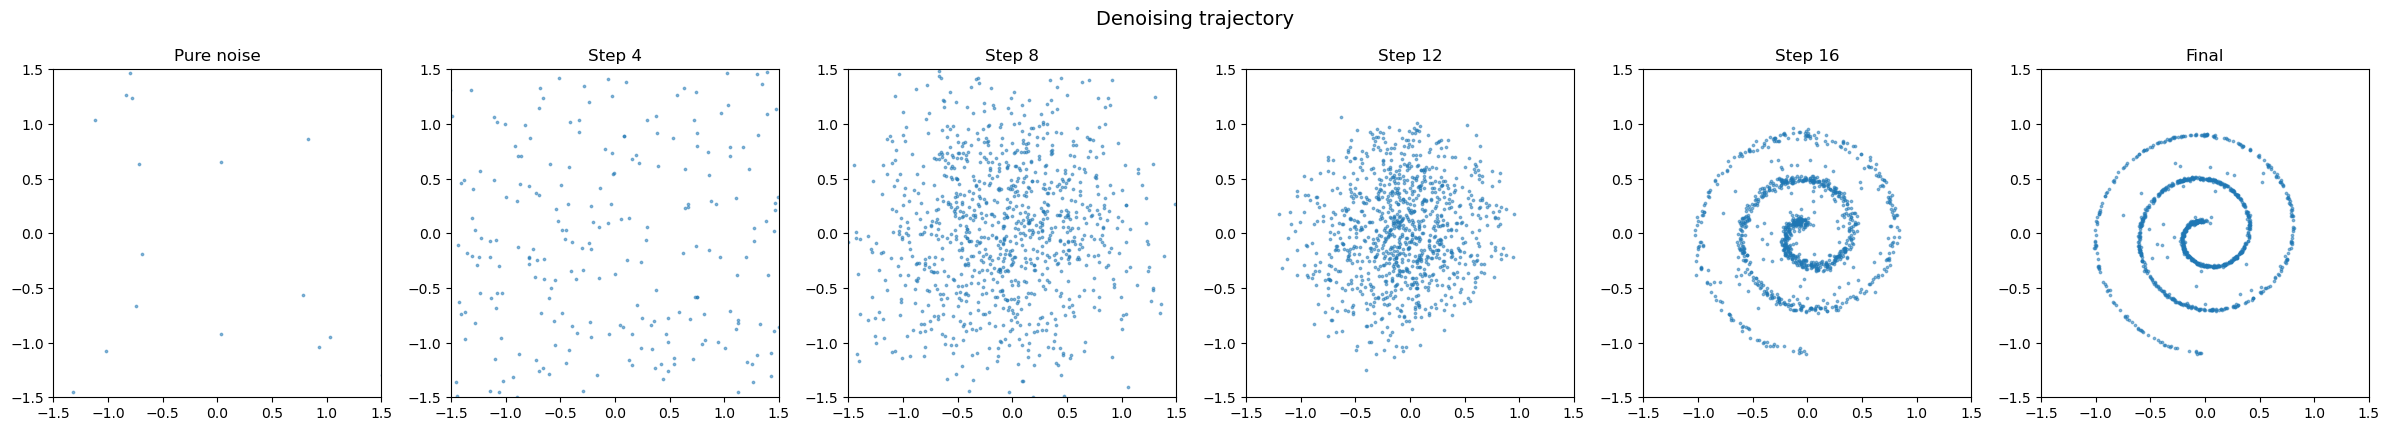

In [14]:
sample_sigs = sample_sigmas(sigmas, 20)
trajectory = sample(model, sample_sigs, n_samples=1000)

# Show every 4th step + the final result
steps_to_show = list(range(0, len(trajectory), 4)) + [len(trajectory) - 1]
steps_to_show = sorted(set(steps_to_show))

fig, axes = plt.subplots(1, len(steps_to_show), figsize=(4 * len(steps_to_show), 4))
for ax, step in zip(axes, steps_to_show):
    pts = trajectory[step].cpu().numpy()
    ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.5)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect("equal")
    label = (
        "Pure noise"
        if step == 0
        else f"Step {step}" if step < len(trajectory) - 1 else "Final"
    )
    ax.set_title(label)
plt.suptitle("Denoising trajectory", y=1.02, fontsize=14)
plt.tight_layout()

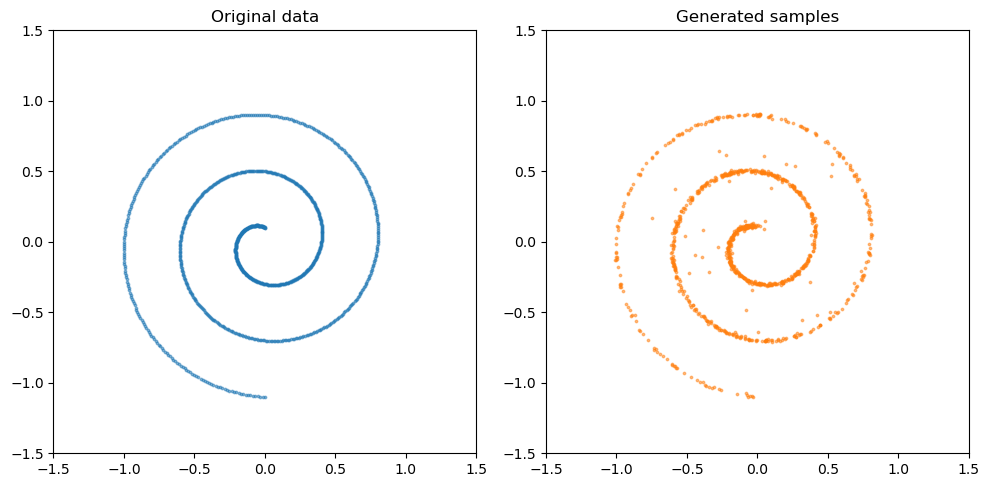

In [15]:
# Final samples vs original data
final = trajectory[-1].cpu().numpy()
orig = dataset.vals.numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].scatter(orig[:, 0], orig[:, 1], s=3, alpha=0.5)
axes[0].set_title("Original data")
axes[0].set_aspect("equal")
axes[1].scatter(final[:, 0], final[:, 1], s=3, alpha=0.5, c="C1")
axes[1].set_title("Generated samples")
axes[1].set_aspect("equal")
for ax in axes:
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
plt.tight_layout()

## 5. Diffusion Samples, Not Inverts

A critical insight: the diffusion model does **not** try to invert the noise to recover the
exact original data point. Instead, it learns the data distribution and **samples
plausible positions** — points that look like they belong to the spiral, but aren't necessarily
where the original point was.

To demonstrate this, let's:
1. Mark the first 10 spiral points as "special" (green stars) and remember their original positions
2. Forward-diffuse the entire dataset to $\sigma_{\max}$: $x_t = x_0 + \sigma_{\max} \cdot \epsilon$
3. Run two **stochastic** sampling processes (DDPM, `mu=0.5`) from the **same** noised data
4. Show that the 10 points land in **different places** each run — and **not** at their original positions

In [16]:
# Take the first 500 data points and forward-diffuse them to sigma_max
n_samples = 1500
n_special = 10

x0_data = dataset.vals[:n_samples].to(device)
x0_special = x0_data[:n_special].clone()  # Remember original positions

# Forward diffuse: x_t = x_0 + sigma_max * eps
torch.manual_seed(42)
eps = torch.randn_like(x0_data)
xt_noised = x0_data + sample_sigs[0] * eps

print(f"Original special points (first 3):\n{x0_special[:3]}")
print(f"\nNoised versions (first 3):\n{xt_noised[:3]}")

Original special points (first 3):
tensor([[-4.3711e-09,  1.0000e-01],
        [-1.5880e-03,  1.0099e-01],
        [-3.2072e-03,  1.0195e-01]], device='cuda:0')

Noised versions (first 3):
tensor([[  1.9402,  -2.2668],
        [ 21.6121, -15.0526],
        [ -1.7237,  10.5639]], device='cuda:0')


In [17]:
@torch.no_grad()
def sample_from_init(model, sigmas, xt_init):
    """DDPM sampling starting from a specific initial noise.
    Stochastic: two runs from the same xt_init will produce different results.
    """
    xt = xt_init.clone()
    trajectory = [xt.clone()]

    for sig, sig_prev in pairwise(sigmas):
        eps = model(xt, sig.expand(xt.shape[0]))
        # DDPM step: partial denoise + fresh noise injection
        sig_p = sig_prev**2 / sig
        eta = (sig_prev**2 - sig_p**2).sqrt()
        xt = xt - (sig - sig_p) * eps + eta * torch.randn_like(xt)
        trajectory.append(xt.clone())

    return trajectory

With `mu=0.5` (DDPM sampling), fresh noise is injected at each denoising step. This means
two runs from the **same** noised input will follow different trajectories and land in different places.

If diffusion were inverting, both runs would recover the original positions. Instead, each run
samples a **different plausible point** on the spiral.

In [18]:
# Both runs start from the SAME noised data
# DDPM sampling injects fresh noise at each step, so results differ
traj_run1 = sample_from_init(model, sample_sigs, xt_noised)
traj_run2 = sample_from_init(model, sample_sigs, xt_noised)

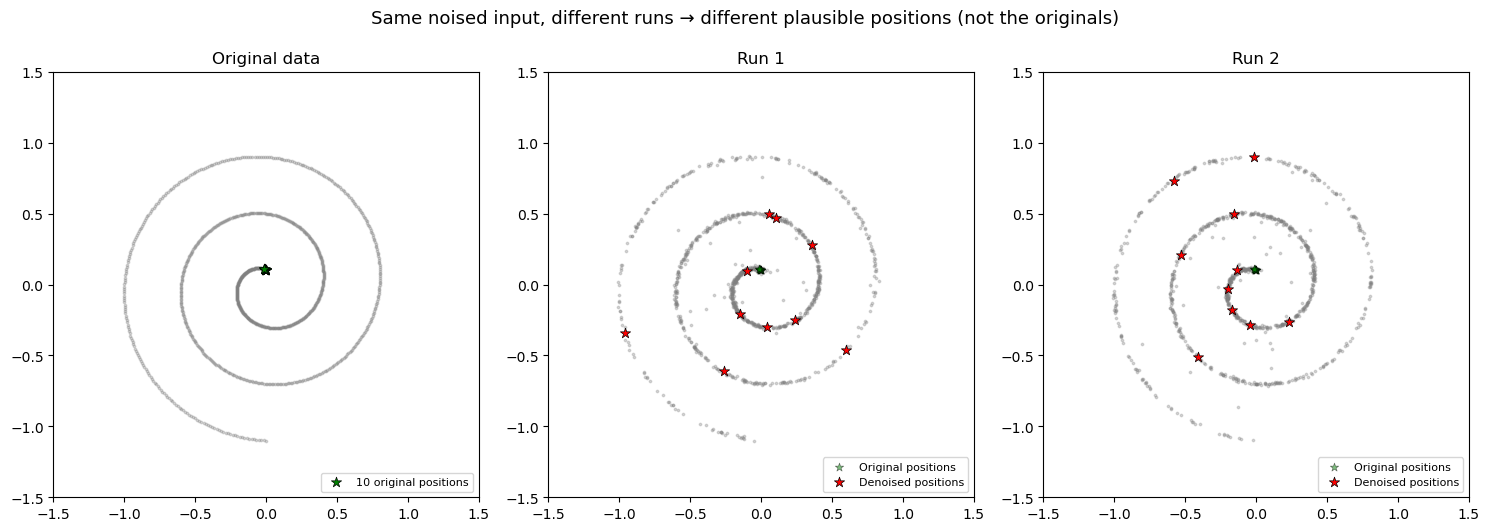

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

orig_np = x0_data.cpu().numpy()
special_np = x0_special.cpu().numpy()

# Original data with 10 special points highlighted
ax = axes[0]
ax.scatter(orig_np[n_special:, 0], orig_np[n_special:, 1], s=3, alpha=0.3, c="gray")
ax.scatter(
    special_np[:, 0],
    special_np[:, 1],
    s=60,
    c="green",
    marker="*",
    zorder=5,
    edgecolors="black",
    linewidths=0.5,
    label=f"{n_special} original positions",
)
ax.set_title("Original data")
ax.legend(fontsize=8, loc="lower right")

# Run 1: show where the 10 special points ended up (red) vs where they started (green)
ax = axes[1]
final1 = traj_run1[-1].cpu().numpy()
ax.scatter(final1[n_special:, 0], final1[n_special:, 1], s=3, alpha=0.3, c="gray")
ax.scatter(
    special_np[:, 0],
    special_np[:, 1],
    s=40,
    c="green",
    marker="*",
    zorder=4,
    alpha=0.5,
    edgecolors="black",
    linewidths=0.5,
    label="Original positions",
)
ax.scatter(
    final1[:n_special, 0],
    final1[:n_special, 1],
    s=60,
    c="red",
    marker="*",
    zorder=5,
    edgecolors="black",
    linewidths=0.5,
    label="Denoised positions",
)
ax.set_title("Run 1")
ax.legend(fontsize=8, loc="lower right")

# Run 2: same layout
ax = axes[2]
final2 = traj_run2[-1].cpu().numpy()
ax.scatter(final2[n_special:, 0], final2[n_special:, 1], s=3, alpha=0.3, c="gray")
ax.scatter(
    special_np[:, 0],
    special_np[:, 1],
    s=40,
    c="green",
    marker="*",
    zorder=4,
    alpha=0.5,
    edgecolors="black",
    linewidths=0.5,
    label="Original positions",
)
ax.scatter(
    final2[:n_special, 0],
    final2[:n_special, 1],
    s=60,
    c="red",
    marker="*",
    zorder=5,
    edgecolors="black",
    linewidths=0.5,
    label="Denoised positions",
)
ax.set_title("Run 2")
ax.legend(fontsize=8, loc="lower right")

for ax in axes:
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect("equal")

plt.suptitle(
    "Same noised input, different runs → different plausible positions (not the originals)",
    y=1.02,
    fontsize=13,
)
plt.tight_layout()

### Zooming in: tracking the 10 points through the denoising process

Let's watch where the 10 special points travel during denoising in both runs.
Green stars show their original positions for reference.

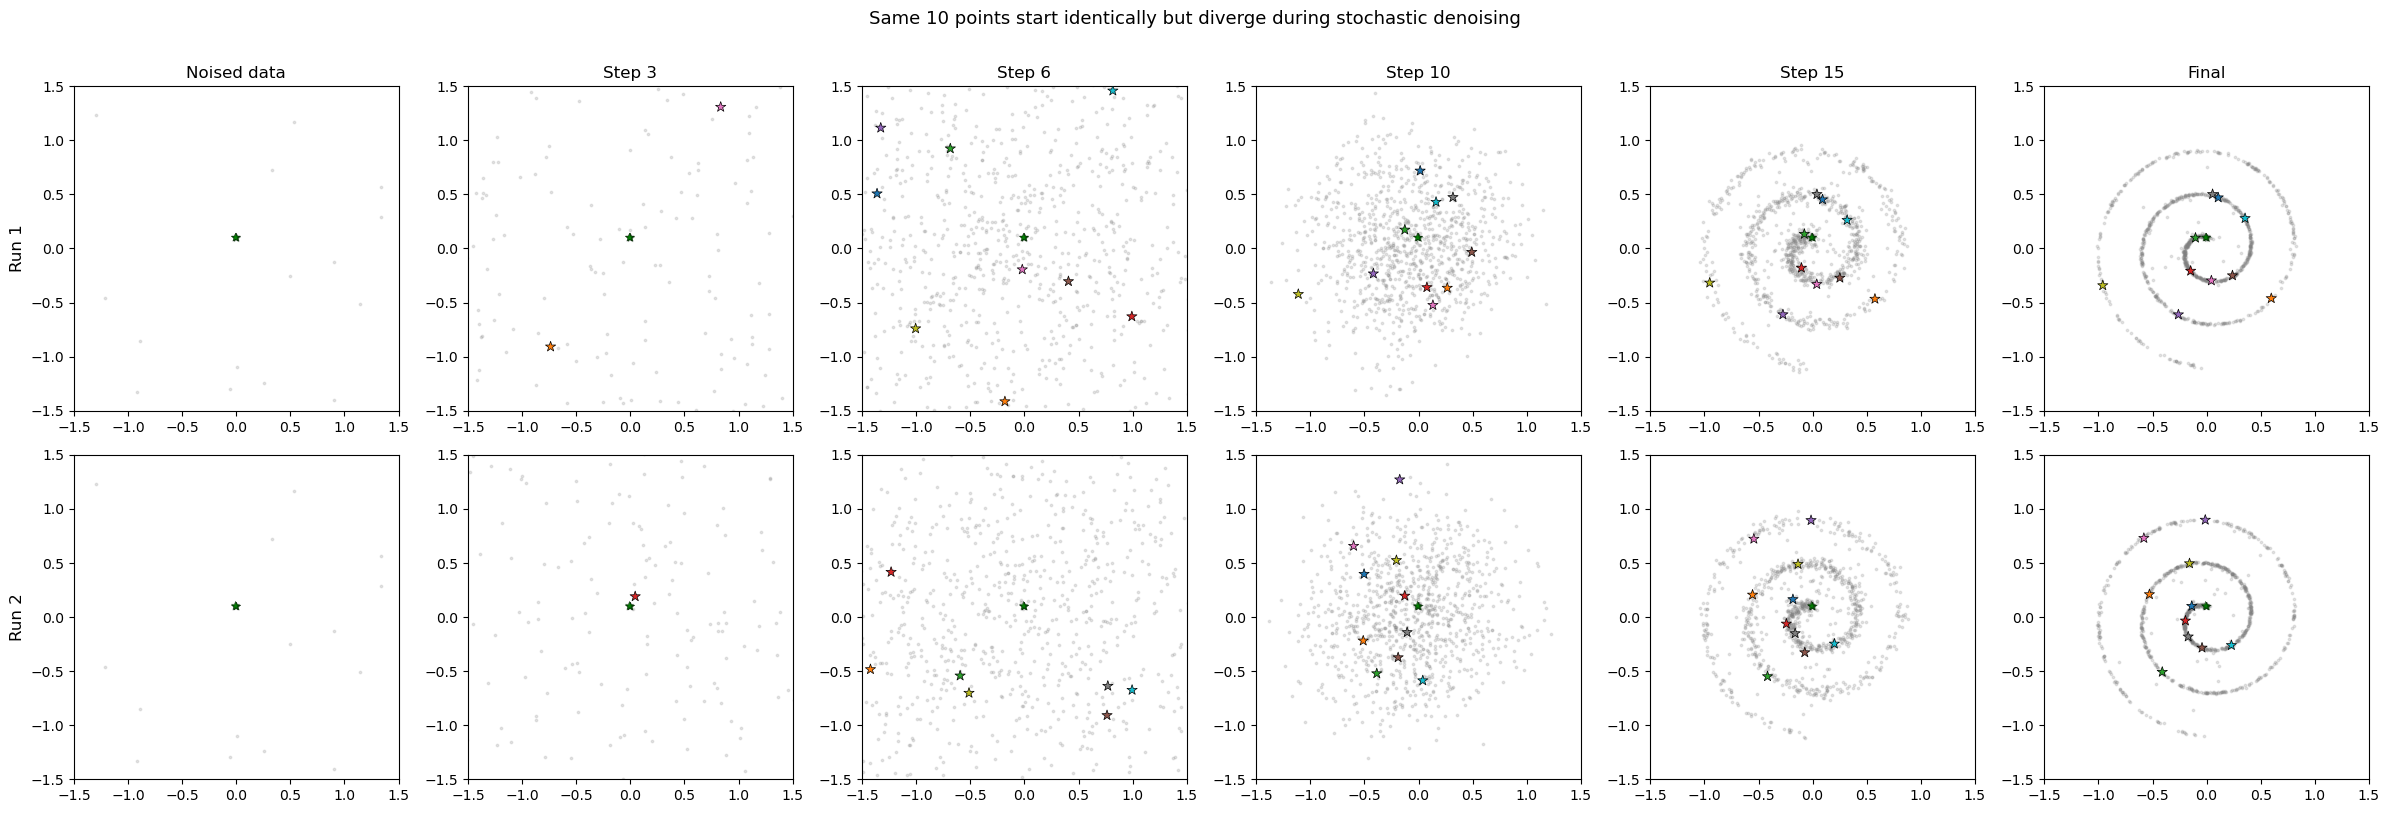

In [20]:
steps_to_show = [0, 3, 6, 10, 15, len(traj_run1) - 1]

fig, axes = plt.subplots(2, len(steps_to_show), figsize=(4 * len(steps_to_show), 8))

for row, (traj, label) in enumerate([(traj_run1, "Run 1"), (traj_run2, "Run 2")]):
    for col, step in enumerate(steps_to_show):
        ax = axes[row, col]
        pts = traj[step].cpu().numpy()
        ax.scatter(pts[n_special:, 0], pts[n_special:, 1], s=3, alpha=0.2, c="gray")
        # Show original positions in green (faded)
        ax.scatter(
            special_np[:, 0],
            special_np[:, 1],
            s=40,
            c="green",
            marker="*",
            zorder=4,
            alpha=0.3,
            edgecolors="black",
            linewidths=0.3,
        )
        # Show current positions with distinct colors
        colors = plt.cm.tab10(np.arange(n_special))
        ax.scatter(
            pts[:n_special, 0],
            pts[:n_special, 1],
            s=60,
            c=colors,
            marker="*",
            zorder=5,
            edgecolors="black",
            linewidths=0.5,
        )
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_aspect("equal")
        if row == 0:
            step_label = (
                "Noised data"
                if step == 0
                else f"Step {step}" if step < len(traj) - 1 else "Final"
            )
            ax.set_title(step_label)
        if col == 0:
            ax.set_ylabel(label, fontsize=12)

plt.suptitle(
    "Same 10 points start identically but diverge during stochastic denoising",
    y=1.01,
    fontsize=13,
)
plt.tight_layout()

In [21]:
# Compare: how far did the 10 points end up from their ORIGINAL positions?
final1_special = traj_run1[-1][:n_special]
final2_special = traj_run2[-1][:n_special]

dist_from_orig_1 = (final1_special - x0_special).norm(dim=1)
dist_from_orig_2 = (final2_special - x0_special).norm(dim=1)
dist_between_runs = (final1_special - final2_special).norm(dim=1)

print("Distance from original position:")
print(f"  {'Point':<8} {'Run 1':>8} {'Run 2':>8} {'Between runs':>14}")
for i in range(n_special):
    print(
        f"  {i:<8} {dist_from_orig_1[i].item():>8.4f} {dist_from_orig_2[i].item():>8.4f} {dist_between_runs[i].item():>14.4f}"
    )

print(
    f"\n  {'Mean':<8} {dist_from_orig_1.mean().item():>8.4f} {dist_from_orig_2.mean().item():>8.4f} {dist_between_runs.mean().item():>14.4f}"
)
print(
    "\nNeither run recovers the original positions, and the two runs disagree with each other."
)
print("The model learned to sample from the distribution, not to invert the noise.")

Distance from original position:
  Point       Run 1    Run 2   Between runs
  0          0.3852   0.1380         0.4430
  1          0.8216   0.5385         1.3109
  2          0.1003   0.7337         0.6794
  3          0.3422   0.2356         0.1800
  4          0.7592   0.7938         1.5293
  5          0.4323   0.3907         0.2834
  6          0.4065   0.8452         1.2012
  7          0.3999   0.3290         0.7187
  8          1.0479   0.4139         1.1590
  9          0.4076   0.4425         0.5542

  Mean       0.5103   0.4861         0.8059

Neither run recovers the original positions, and the two runs disagree with each other.
The model learned to sample from the distribution, not to invert the noise.
